Top 2 eigenvalues:
[4.22824171 0.24267075]
Explained variance ratio:
[0.92461872 0.05306648]


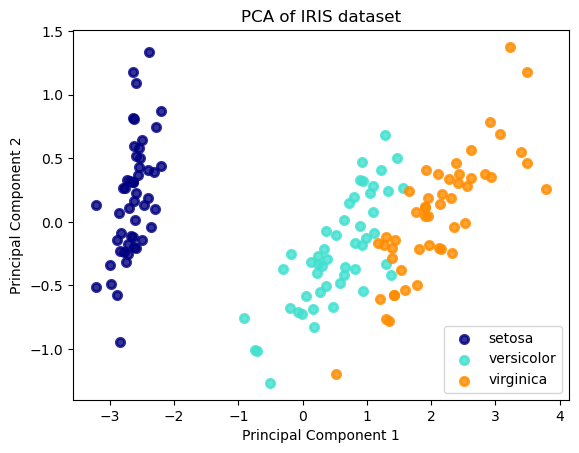

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

%matplotlib inline

# 载入 iris 数据集
iris = datasets.load_iris()

# 特征向量为 4 维
X = iris.data

# 标签值，用于将样本显示成不同颜色
y = iris.target
target_names = iris.target_names

# 创建PCA对象，将4维数据降到2维(Iris数据集是四维的)
pca = PCA(n_components=2)
X_r = pca.fit_transform(X)

# 输出协方差矩阵最大的两个特征值
print("Top 2 eigenvalues:")
print(pca.explained_variance_)

# 输出两个主成分的方差贡献率
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

plt.figure()

colors = ['navy', 'turquoise', 'darkorange']
lw = 2

# 显示降维后的样本
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_r[y == i, 0],X_r[y == i, 1],color=color,alpha=0.8,lw=lw,label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

适合使用PCA的例子

原始数据维度: (500, 3)

========== 指标一：特征相关系数矩阵 ==========
[[ 1.          0.99316968 -0.98635487]
 [ 0.99316968  1.         -0.9888951 ]
 [-0.98635487 -0.9888951   1.        ]]
判断方法：
如果不同特征之间的 |相关系数| 较大，说明特征之间存在较强线性相关，
数据中可能存在冗余信息，因此比较适合使用 PCA 压缩维度。

========== 指标二：各主成分的方差贡献率 ==========
协方差矩阵的特征值:
[2.98491894 0.01453073 0.00656236]

各主成分的方差贡献率:
[0.99298303 0.00483389 0.00218308]
PC1: 99.30%
PC2: 0.48%
PC3: 0.22%

判断方法：
如果前几个主成分的方差贡献率很高，
说明数据的大部分变化集中在少数几个方向上，适合 PCA 降维。

========== 指标三：累计方差贡献率 ==========
前 1 个主成分累计保留: 99.30%
前 2 个主成分累计保留: 99.78%
前 3 个主成分累计保留: 100.00%

达到 90% 方差需要 1 个主成分
达到 95% 方差需要 1 个主成分

判断方法：
如果原始维度很多，而只需要少数几个主成分就能达到 90%~95%，
说明 PCA 可以有效降维。
如果需要保留几乎所有主成分才能达到 90%~95%，
说明 PCA 的降维效果有限。

========== PCA 适用性判断 ==========
原始数据有 3 维，只需要 1 个主成分就能保留至少 95% 的方差。
因此：该数据具有明显的低维线性结构，适合使用 PCA 降维。

降维后的数据维度: (500, 1)
只保留 PC1 时保留的方差: 99.30%


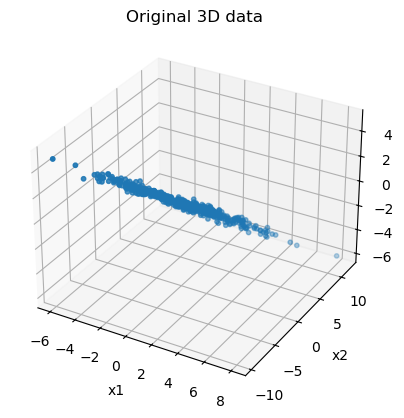

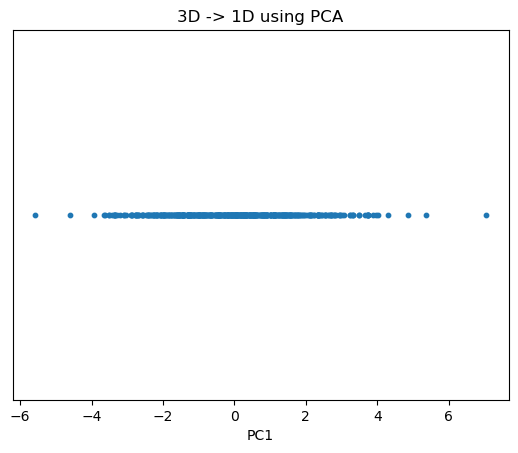

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# 1. 构造三维线性相关数据
# =========================
np.random.seed(42)

n = 500
t = np.random.normal(0, 1, n)

x1 = 2.0 * t + np.random.normal(0, 0.2, n)
x2 = 3.0 * t + np.random.normal(0, 0.2, n)
x3 = -1.5 * t + np.random.normal(0, 0.2, n)

X = np.column_stack((x1, x2, x3))

print("原始数据维度:", X.shape)

# =========================
# 2. 指标一：特征相关系数矩阵
# =========================
corr = np.corrcoef(X, rowvar=False)

print("\n========== 指标一：特征相关系数矩阵 ==========")
print(corr)
print("判断方法：")
print("如果不同特征之间的 |相关系数| 较大，说明特征之间存在较强线性相关，")
print("数据中可能存在冗余信息，因此比较适合使用 PCA 压缩维度。")

# =========================
# 3. 标准化
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA
# =========================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(variance_ratio)

# =========================
# 5. 指标二：特征值和方差贡献率
# =========================
print("\n========== 指标二：各主成分的方差贡献率 ==========")

print("协方差矩阵的特征值:")
print(eigenvalues)

print("\n各主成分的方差贡献率:")
print(variance_ratio)

for i, ratio in enumerate(variance_ratio):
    print(f"PC{i+1}: {ratio * 100:.2f}%")

print("\n判断方法：")
print("如果前几个主成分的方差贡献率很高，")
print("说明数据的大部分变化集中在少数几个方向上，适合 PCA 降维。")

# =========================
# 6. 指标三：累计方差贡献率
# =========================
print("\n========== 指标三：累计方差贡献率 ==========")

for i, ratio in enumerate(cumulative_ratio):
    print(f"前 {i+1} 个主成分累计保留: {ratio * 100:.2f}%")

n90 = np.argmax(cumulative_ratio >= 0.90) + 1
n95 = np.argmax(cumulative_ratio >= 0.95) + 1

print(f"\n达到 90% 方差需要 {n90} 个主成分")
print(f"达到 95% 方差需要 {n95} 个主成分")

print("\n判断方法：")
print("如果原始维度很多，而只需要少数几个主成分就能达到 90%~95%，")
print("说明 PCA 可以有效降维。")
print("如果需要保留几乎所有主成分才能达到 90%~95%，")
print("说明 PCA 的降维效果有限。")

# =========================
# 7. 给出本数据的简单判断
# =========================
print("\n========== PCA 适用性判断 ==========")

if n95 < X.shape[1]:
    print(
        f"原始数据有 {X.shape[1]} 维，只需要 {n95} 个主成分"
        f"就能保留至少 95% 的方差。"
    )
    print("因此：该数据具有明显的低维线性结构，适合使用 PCA 降维。")
else:
    print("需要保留几乎全部主成分才能达到 95% 的累计方差。")
    print("因此：PCA 的降维价值较有限。")

# =========================
# 8. 降到一维
# =========================
pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X_scaled)

print("\n降维后的数据维度:", X_1d.shape)
print(f"只保留 PC1 时保留的方差: {pca_1d.explained_variance_ratio_[0] * 100:.2f}%")

# =========================
# 9. 原始三维数据
# =========================
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=10)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Original 3D data")

plt.show()

# =========================
# 10. PCA 降到一维
# =========================
plt.figure()

plt.scatter(X_1d[:, 0], np.zeros(n), s=10)

plt.xlabel("PC1")
plt.yticks([])
plt.title("3D -> 1D using PCA")

plt.show()

不适合使用PCA的例子

原始数据维度: (500, 3)

========== 指标一：特征相关系数矩阵 ==========
[[ 1.         -0.07567075 -0.05779053]
 [-0.07567075  1.          0.07603839]
 [-0.05779053  0.07603839  1.        ]]

判断方法：
如果非对角元素都接近 0，说明不同特征之间基本没有线性相关，
不存在明显的线性冗余信息。

========== 指标二：协方差矩阵特征值 ==========
[1.14227796 0.94409929 0.91963478]

判断方法：
如果最大的几个特征值没有明显大于其他特征值，
说明数据没有明显的主要变化方向。

========== 指标三：各主成分方差贡献率 ==========
PC1: 38.00%
PC2: 31.41%
PC3: 30.59%

判断方法：
如果方差比较平均地分布在所有主成分中，
说明删除任何一个主成分都会损失较多信息。

========== 指标四：累计方差贡献率 ==========
前 1 个主成分累计保留: 38.00%
前 2 个主成分累计保留: 69.41%
前 3 个主成分累计保留: 100.00%

达到 90% 方差需要 3 个主成分
达到 95% 方差需要 3 个主成分

========== PCA 适用性判断 ==========
原始数据只有 3 维，但需要保留 3 个主成分才能达到 95% 的累计方差。
因此：PCA 基本无法有效压缩维度，不适合用于明显降维。


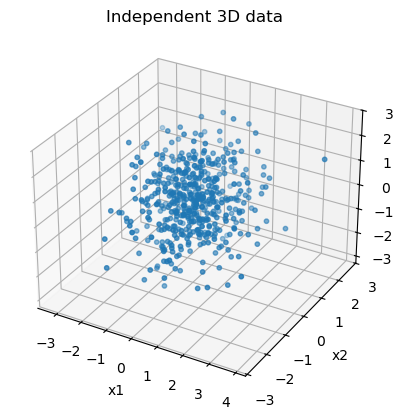

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =========================
# 1. 构造三个相互独立的特征
# =========================
np.random.seed(42)

n = 500

x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
x3 = np.random.normal(0, 1, n)

X = np.column_stack((x1, x2, x3))

print("原始数据维度:", X.shape)

# =========================
# 2. 指标一：相关系数矩阵
# =========================
corr = np.corrcoef(X, rowvar=False)

print("\n========== 指标一：特征相关系数矩阵 ==========")
print(corr)

print("\n判断方法：")
print("如果非对角元素都接近 0，说明不同特征之间基本没有线性相关，")
print("不存在明显的线性冗余信息。")

# =========================
# 3. 标准化
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA
# =========================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_
cumulative_ratio = np.cumsum(variance_ratio)

# =========================
# 5. 指标二：特征值
# =========================
print("\n========== 指标二：协方差矩阵特征值 ==========")
print(eigenvalues)

print("\n判断方法：")
print("如果最大的几个特征值没有明显大于其他特征值，")
print("说明数据没有明显的主要变化方向。")

# =========================
# 6. 指标三：方差贡献率
# =========================
print("\n========== 指标三：各主成分方差贡献率 ==========")

for i, ratio in enumerate(variance_ratio):
    print(f"PC{i+1}: {ratio * 100:.2f}%")

print("\n判断方法：")
print("如果方差比较平均地分布在所有主成分中，")
print("说明删除任何一个主成分都会损失较多信息。")

# =========================
# 7. 累计方差贡献率
# =========================
print("\n========== 指标四：累计方差贡献率 ==========")

for i, ratio in enumerate(cumulative_ratio):
    print(f"前 {i+1} 个主成分累计保留: {ratio * 100:.2f}%")

n90 = np.argmax(cumulative_ratio >= 0.90) + 1
n95 = np.argmax(cumulative_ratio >= 0.95) + 1

print(f"\n达到 90% 方差需要 {n90} 个主成分")
print(f"达到 95% 方差需要 {n95} 个主成分")

# =========================
# 8. PCA 适用性判断
# =========================
print("\n========== PCA 适用性判断 ==========")

if n95 < X.shape[1]:
    print("少数主成分即可保留大部分方差，PCA 有明显降维价值。")
else:
    print(
        f"原始数据只有 {X.shape[1]} 维，但需要保留 {n95} 个主成分"
        "才能达到 95% 的累计方差。"
    )
    print("因此：PCA 基本无法有效压缩维度，不适合用于明显降维。")

# =========================
# 9. 原始三维数据
# =========================
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=10)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Independent 3D data")

plt.show()